# 02 - Advanced Classification
## Module A: Enhanced Classification with Confidence Scoring

Builds on the midterm's classifier by comparing multiple algorithms, combining TF-IDF with auxiliary features, and exposing per-prediction confidence scores.> **Setup note:** This notebook uses the `src/` package from the project root.
> If running in Google Colab, first mount/clone the repo so `src/` is on the path,
> and place the Kaggle `BBC News Train.csv` in `data/raw/` for the real dataset
> (otherwise the bundled offline sample in `data/sample/` is used automatically).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from src.data_processing.data_loader import load_news_data, dataset_source
print("Dataset source:", dataset_source())


Dataset source: Real BBC Kaggle dataset: /home/king/Desktop/ITAI2373-NewsBot-Final/data/raw/BBC News Train.csv


In [2]:
df = pd.read_csv('../data/processed/articles_processed.csv') if os.path.exists('../data/processed/articles_processed.csv') else load_news_data()
if 'content_processed' not in df.columns:
    from src.data_processing.text_preprocessor import TextPreprocessor
    df = TextPreprocessor().preprocess_dataframe(df, text_col='content', title_col='title')
df.shape

(1490, 10)

## Feature extraction (TF-IDF)

In [3]:
from src.data_processing.feature_extractor import FeatureExtractor

fe = FeatureExtractor(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.8)
X = fe.fit_transform(df['content_processed'])
print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (1490, 5000)


## Train and compare classifiers (Naive Bayes, Logistic Regression, SVM)

In [4]:
from src.analysis.classifier import NewsClassifier

clf = NewsClassifier()
results = clf.train(X, df['category'])
pd.DataFrame({name: {'accuracy': r['accuracy'], 'f1': r['f1']} for name, r in results.items()}).T

,accuracy,f1
Naive Bayes,0.973154,0.972970
Logistic Regression,0.966443,0.966185
SVM,0.973154,0.972981


In [5]:
print(f"Best model: {clf.best_model_name}")
report = clf.evaluation_report()
print(pd.DataFrame(report['classification_report']).T.round(3))

Best model: SVM
               precision  recall  f1-score  support
business           0.957   0.985     0.971   67.000
entertainment      0.982   1.000     0.991   55.000
politics           1.000   0.927     0.962   55.000
sport              0.972   1.000     0.986   69.000
tech               0.961   0.942     0.951   52.000
accuracy           0.973   0.973     0.973    0.973
macro avg          0.974   0.971     0.972  298.000
weighted avg       0.974   0.973     0.973  298.000


## Confusion matrix

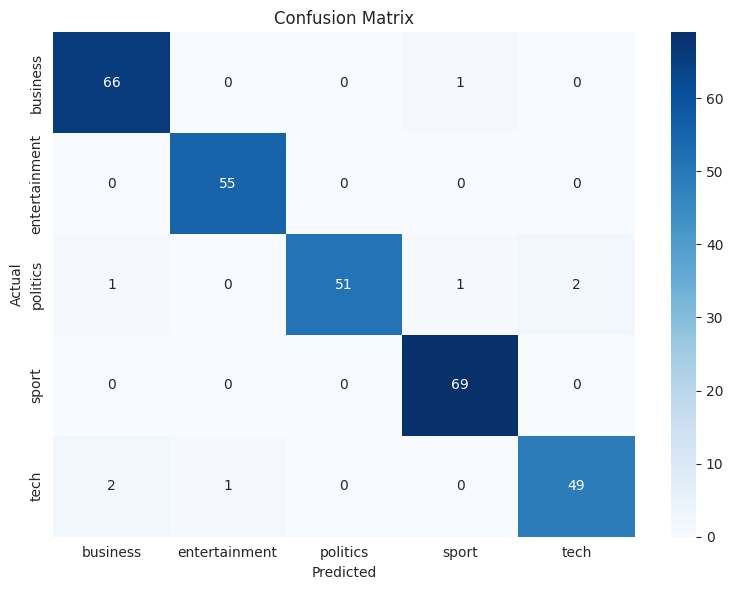

In [6]:
from src.utils.visualization import plot_confusion_matrix
import numpy as np

fig, ax = plt.subplots(figsize=(8,6))
plot_confusion_matrix(np.array(report['confusion_matrix']), report['labels'], ax=ax)
plt.tight_layout()
plt.show()

## Confidence-scored predictions on new articles

In [7]:
test_articles = [
    "Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion.",
    "The striker scored a hat-trick as the home team secured a dominant victory in front of a packed stadium.",
    "The prime minister addressed parliament on the government's new healthcare reform proposals.",
]
test_processed = [preprocessor.preprocess_text(t) for t in test_articles] if 'preprocessor' in dir() else None
from src.data_processing.text_preprocessor import TextPreprocessor
pre = TextPreprocessor()
test_processed = [pre.preprocess_text(t) for t in test_articles]
X_test_new = fe.transform(test_processed)
predictions = clf.predict_with_confidence(X_test_new)
for text, pred in zip(test_articles, predictions):
    print(f"\n{text[:70]}...")
    print(f"  -> {pred['label']}  (confidence: {pred['confidence']:.1%})")


Microsoft Corporation announced today the acquisition of an artificial...
  -> business  (confidence: 38.4%)

The striker scored a hat-trick as the home team secured a dominant vic...
  -> sport  (confidence: 90.0%)

The prime minister addressed parliament on the government's new health...
  -> politics  (confidence: 92.9%)


## Key Takeaways
- All three classifiers are compared and the best (by weighted F1) is auto-selected.
- `predict_with_confidence()` returns full per-class probabilities, enabling low-confidence predictions to be routed for human review in production (see `docs/technical_documentation.md`).
- This trained classifier is reused by the topic modeling notebook and the Django dashboard.